In [1]:
DATASET_NAME = "mimic_iv_cohort"
TEST_SIZE = 0.2
SEED = 4

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '..'
  SRC = f"{PROJECT_ROOT}/src"
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
  if SRC not in sys.path:
    sys.path.append(SRC)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from config import Config

In [4]:

cohort = pd.read_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/{DATASET_NAME}.csv")

In [5]:
print(f"Current features: {cohort.shape[1] - 1}")
print(f"Current population: {cohort.shape[0]}")

Current features: 70
Current population: 13890


# Missingness

- Remove features with more than 25% missing values
- Remove rows with more than 20% features missing
- Multivariate imputer for remaining missing values (in the training loop, stratified by ethnicity)

## Drop columns

In [6]:
# Drop columns with > 25% missing values in any ethnicity subgroup
missing_ratio = cohort.isna().mean()
subgroup_missing = cohort.isna().groupby(cohort['race_group']).mean()

cols_to_drop = list(set(missing_ratio[missing_ratio > 0.25].index.tolist() + subgroup_missing.columns[(subgroup_missing > 0.25).any()].tolist()))

study_dataset = cohort.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining features: {study_dataset.shape[1] - 1}")
print(f"Current population: {study_dataset.shape[0]}")

Dropped 9 columns: ['ck_mb_min', 'ntbnp_max', 'bilirubin_max', 'ck_cpk_max', 'ck_cpk_min', 'fio2_max', 'pao2_min', 'ck_mb_max', 'ntbnp_min']
Remaining features: 61
Current population: 13890


## Sieve analysis

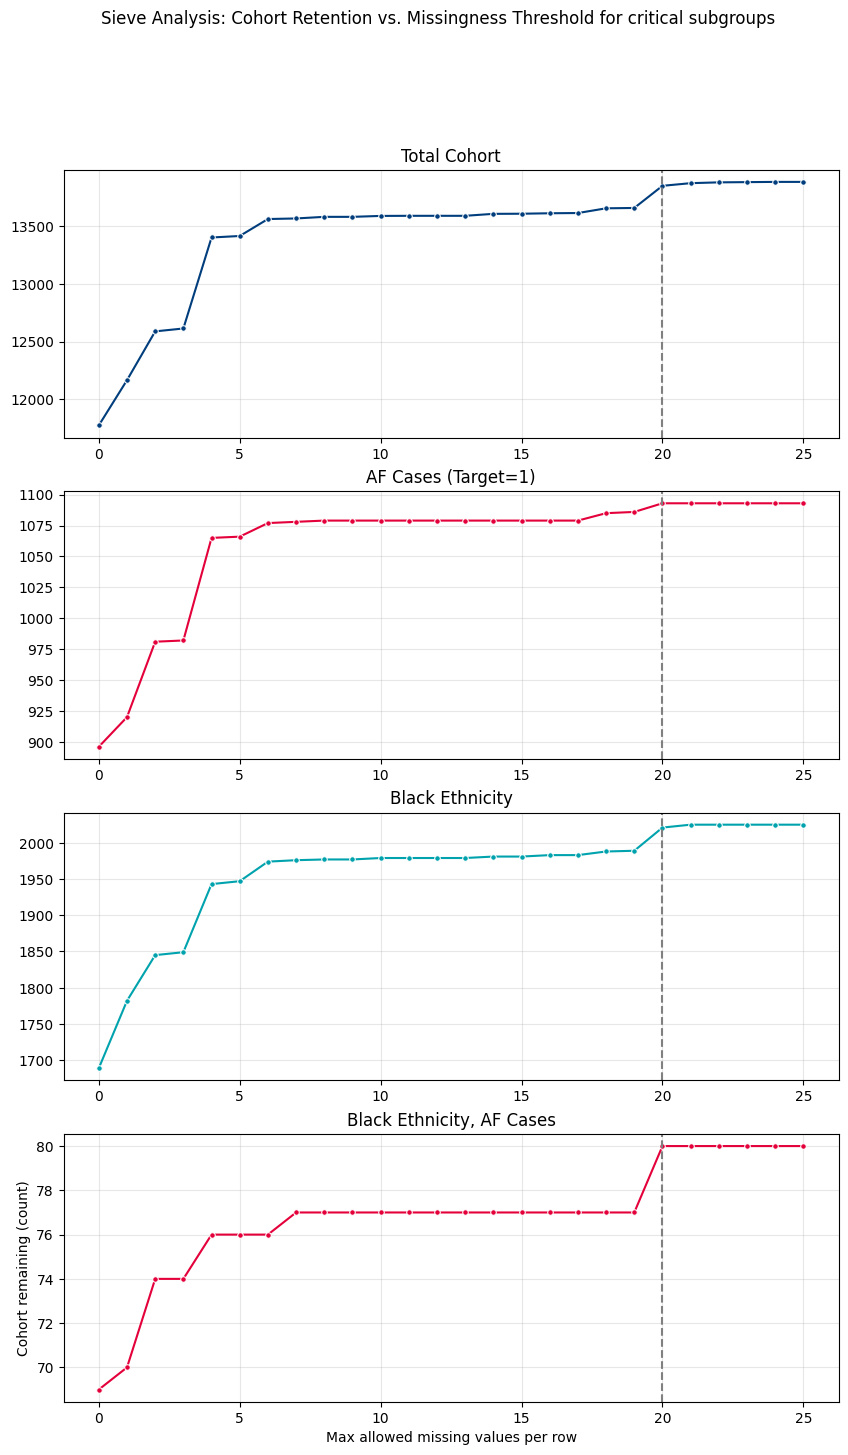

In [7]:
df_af = study_dataset[study_dataset['target_noaf'] == 1]
df_non_white = study_dataset[study_dataset['race_group'] != 0]
df_non_white_af = df_non_white[df_non_white['target_noaf'] == 1]

groups = {
  'Total Cohort': study_dataset,
  'AF Cases (Target=1)': df_af,
  'Black Ethnicity': df_non_white,
  'Black Ethnicity, AF Cases': df_non_white_af
}

thresholds = range(0, 26)
results = {name: [] for name in groups.keys()}

for t in thresholds:
  for name, subset in groups.items():
    # Count how many in this subset have <= t missing values
    n_missing = subset.isna().sum(axis=1)
    n_retained = len(subset) - sum(n_missing > t)
    results[name].append(n_retained)

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
colors = ['#003d7c', '#e4003a', '#00a3ad', '#e4003a']
ax_idx = [0, 1, 2, 3]

for (name, counts), color, ax in zip(results.items(), colors, ax_idx):
  sns.lineplot(x=thresholds, y=counts, color=color, marker='o', markersize=4, ax=axes[ax])
  axes[ax].axvline(x=20, color='gray', linestyle='--', label='Candidate Threshold (20)')
  axes[ax].grid(True, alpha=0.3)
  axes[ax].set_title(name)

plt.suptitle('Sieve Analysis: Cohort Retention vs. Missingness Threshold for critical subgroups')
plt.xlabel('Max allowed missing values per row')
plt.ylabel('Cohort remaining (count)')
plt.show()

# Interpretation:
# If the three lines stay close together, the missingness is non differential, 
# i.e. low quality rows are distributed evenly across the population 
# and can be dealt with without introducing selection bias
# If the Non-White and AF lines drop significantly faster than the global population => differential missingness
# => relax the threshold or use imputation to preserve sample diversity
# However, this can show how data processing might affect bias in datasets

## Drop rows

In [8]:
# Drop rows with more than 7% missing features before imputation
chosen_threshold = 0.2
max_missing = study_dataset.shape[1] * chosen_threshold

missing_per_row = study_dataset.isna().sum(axis=1)

study_dataset = study_dataset.loc[missing_per_row <= max_missing, :].copy()

print(f"Rows dropped: {(missing_per_row > max_missing).sum(axis=0)}")
print(f"Remaining cohort size: {len(study_dataset)}")
print(f"Features: {study_dataset.shape[1]}")
print("Class and ethinicity split:")
print(study_dataset.groupby(['target_noaf','race_group']).size())

Rows dropped: 299
Remaining cohort size: 13591
Features: 62
Class and ethinicity split:
target_noaf  race_group
0            0             10610
             1              1902
1            0              1002
             1                77
dtype: int64


## Missingness matrix

<Axes: >

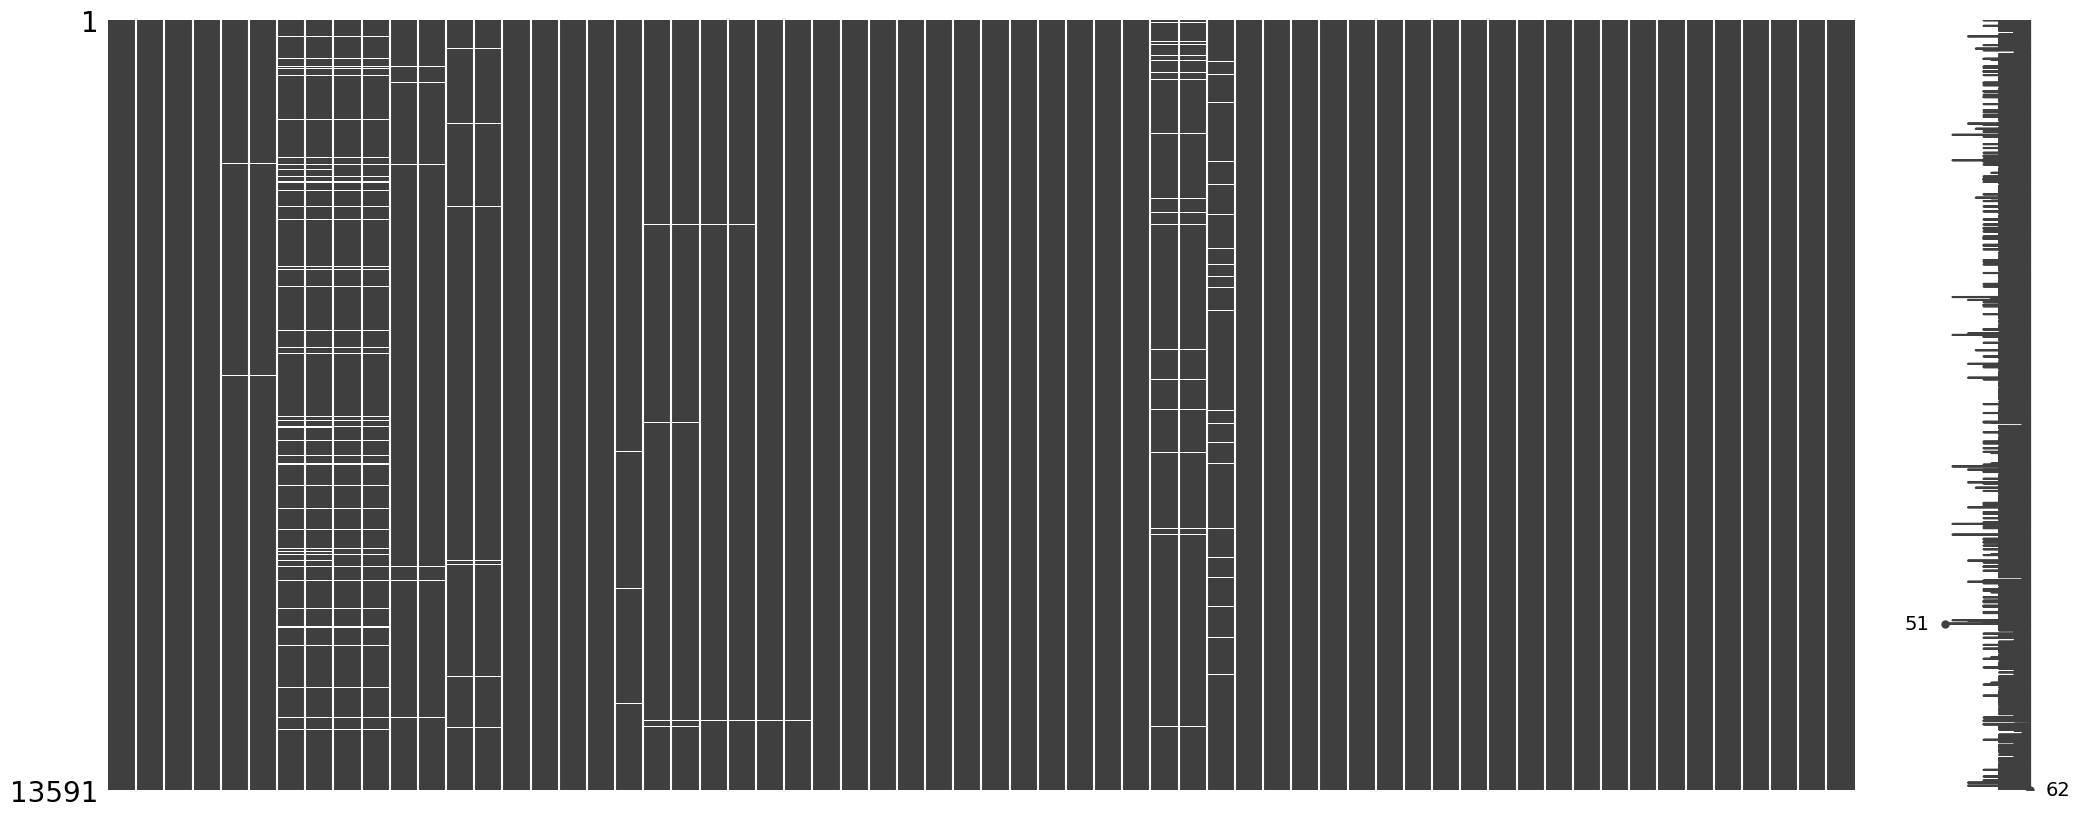

In [9]:
msno.matrix(study_dataset)

## Table 1

In [11]:
from tableone import TableOne

categorical_features = (
  ["target_noaf", "race_group", "gender"] + 
  [col for col in study_dataset.columns 
  if ((col.startswith('sofa_') and col != "sofa_total") 
      or col.startswith('comorb_') or col.startswith('gcs_'))] +
  ["vent_day1", "crrt_day1", "antibiotics_day1"])
continuous_features = [col for col in study_dataset.columns 
  if col not in categorical_features]

# Descriptive statistics
table1 = TableOne(study_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  normal_test=True,
                  tukey_test=True,
                  dip_test=True,
                  missing=True,
                  show_histograms=True
                  )

print(table1)

                                        Grouped by race_group                                                                                             
                                                      Missing          Overall                0                1 0 Histogram 1 Histogram Overall Histogram
n                                                                        13591            11612             1979                                          
gender, n (%)                      0                               7053 (51.9)      6123 (52.7)       930 (47.0)                                          
                                   1                               6538 (48.1)      5489 (47.3)      1049 (53.0)                                          
admission_age, mean (SD)                                    0      62.3 (16.7)      62.7 (16.6)      59.7 (17.0)    ▂▂▃▆█▆▆▄    ▃▃▄▅▇█▅▃          ▂▂▃▅█▇▆▄
hr_min, mean (SD)                                           0      71.

## TRAINING / TEST split

In [12]:
from sklearn.model_selection import train_test_split

strata = study_dataset[['target_noaf', 'race_group']]

train_df, test_df = train_test_split(
  study_dataset, 
  test_size=TEST_SIZE, 
  stratify=strata, 
  random_state=SEED
)

In [13]:
print(f"CEVAE-HE Training Set Size: {len(train_df)}")
print(f"CEVAE-HE Test and Classifier Bootstrap Set Size: {len(test_df)}")

print("\nTraining Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(train_df['race_group'], train_df['target_noaf']).to_markdown())

print("\nTest Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(test_df['race_group'], test_df['target_noaf']).to_markdown())

CEVAE-HE Training Set Size: 10872
CEVAE-HE Test and Classifier Bootstrap Set Size: 2719

Training Set Ethnicity Distribution by Target Outcome:
|   race_group |    0 |   1 |
|-------------:|-----:|----:|
|            0 | 8487 | 802 |
|            1 | 1521 |  62 |

Test Set Ethnicity Distribution by Target Outcome:
|   race_group |    0 |   1 |
|-------------:|-----:|----:|
|            0 | 2123 | 200 |
|            1 |  381 |  15 |


# Feature transformation

In [14]:
# Drop gcs scores, already embedded in the SOFA score
gcs_cols = [col for col in categorical_features 
  if (col.startswith('gcs_'))]

test_df.drop(columns=gcs_cols, inplace=True)
train_df.drop(columns=gcs_cols, inplace=True)

## Global Scaling

This is a conscious choice, as I need to train my CEVAE-HE before training my classifiers, and therefore need a consistently scaled dataset rather than applying scaling within bootstrapping loops

In [16]:
from processing_utils import ZeroInflatedConditionalScaler, StrataAwareRobustScaler

sens_col = "race_group"

zero_inflated_features = [
  "max_norepinephrine_rate",
  "max_epinephrine_rate",
  "max_dopamine_rate"
]

multimodal_features = [col for col in continuous_features
  if col not in zero_inflated_features]

ordinal_scores = [col for col in categorical_features 
  if (col.startswith('sofa_'))]

scaled_train_df = train_df.copy()
scaled_test_df = test_df.copy()

In [17]:
zi_scaler = ZeroInflatedConditionalScaler(infusion_cols=zero_inflated_features)
scaled_train_df = zi_scaler.fit_transform(scaled_train_df)
scaled_test_df = zi_scaler.transform(scaled_test_df)

strata_scaler = StrataAwareRobustScaler(strata_col=sens_col, continuous_cols=multimodal_features)
scaled_train_df = strata_scaler.fit_transform(scaled_train_df)
scaled_test_df = strata_scaler.transform(scaled_test_df)

scaled_train_df, scaled_test_df = scaled_train_df.align(scaled_test_df, join='left', axis=1)

## Ordinal encoding

In [18]:
def encode_ordinal_scores(df):
    df_out = df.copy()
    for col in ordinal_scores:  
        # Create a binary indicator for each threshold step starting from 1 up to (max_val - 1)
        for threshold in range(0, 4):
            new_col_name = f"{col}_gt_{threshold}"
            df_out[new_col_name] = (df_out[col] >= threshold).astype(float)
        
        # Drop the original raw integer column
        df_out = df_out.drop(columns=[col])

    return df_out

scaled_train_df = encode_ordinal_scores(scaled_train_df)
scaled_test_df = encode_ordinal_scores(scaled_test_df)


In [19]:
# print(scaled_train_df.filter(regex="sofa_.*").head(5).T)

## TRAIN split table one

In [20]:
categorical_features = [col for col in scaled_train_df if col not in (continuous_features + ['race_group'])]
# TRAIN split: Descriptive statistics
table1 = TableOne(scaled_train_df,
                  groupby='race_group',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=True,
                  show_histograms=True
                  )

print(table1)

                                             Grouped by race_group                                                                                     
                                                           Missing        Overall             0             1 0 Histogram 1 Histogram Overall Histogram
n                                                                           10872          9289          1583                                          
gender, n (%)                            0                            5626 (51.7)   4885 (52.6)    741 (46.8)                                          
                                         1                            5246 (48.3)   4404 (47.4)    842 (53.2)                                          
admission_age, mean (SD)                                         0     -0.1 (0.8)    -0.1 (0.8)    -0.1 (0.7)    ▂▂▃▅█▇▆▄    ▃▃▄▆▆█▅▄          ▂▂▃▅█▇▅▄
hr_min, mean (SD)                                                0      0.1 (0.8)     0.

# Imputation

In [21]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [22]:
def print_missing_report(df, label="Dataset"):
  total_cells = np.prod(df.shape)
  missing_count = df.isnull().sum()
  total_missing = missing_count.sum()
  
  print(f"--- {label} Missingness Report ---")
  print(f"Total rows: {df.shape[0]}, Total features: {df.shape[1]}")
  print(f"Total missing values: {total_missing} ({ (total_missing/total_cells)*100:.4f}% of data)")
  
  # Filter only columns with missing data
  missing_cols = missing_count[missing_count > 0].sort_values(ascending=False)
  if not missing_cols.empty:
    summary_df = pd.DataFrame({
      'Missing Count': missing_cols,
      'Percentage (%)': (missing_cols / len(df)) * 100
    })
    print("\nTop features with missing values:")
    print(summary_df.head(10).to_string())
  else:
    print("\nNo missing values found.")
  print("-" * 35 + "\n")
  
  return missing_cols.head(10).index.to_list()

train_top_missing_cols = print_missing_report(scaled_train_df, "TRAINING SET")
test_top_missing_cols = print_missing_report(scaled_test_df, "TEST SET")

# Is missingness biased by ethnicity?
eth_missing = scaled_train_df.groupby('race_group').apply(
    lambda x: x.isnull().mean().mean(), 
    include_groups=False)
print("Average missingness rate by Ethnicity (Training Set):")
print(eth_missing)

--- TRAINING SET Missingness Report ---
Total rows: 10872, Total features: 80
Total missing values: 4526 (0.5204% of data)

Top features with missing values:
                    Missing Count  Percentage (%)
sbp_min                       721        6.631714
sbp_max                       721        6.631714
dbp_min                       690        6.346578
dbp_max                       690        6.346578
urine_output_total            308        2.832965
calcium_max                   221        2.032745
calcium_min                   221        2.032745
temp_max                      125        1.149742
temp_min                      125        1.149742
hemoglobin_max                 74        0.680648
-----------------------------------

--- TEST SET Missingness Report ---
Total rows: 2719, Total features: 80
Total missing values: 1101 (0.5062% of data)

Top features with missing values:
                    Missing Count  Percentage (%)
sbp_max                       173        6.362633
sb

In [23]:
cols_to_impute = multimodal_features
print(multimodal_features)

['admission_age', 'hr_min', 'hr_max', 'rr_min', 'rr_max', 'sbp_min', 'sbp_max', 'dbp_min', 'dbp_max', 'mbp_min', 'mbp_max', 'temp_min', 'temp_max', 'spo2_min', 'weight', 'hemoglobin_min', 'hemoglobin_max', 'wbc_min', 'wbc_max', 'platelets_min', 'platelets_max', 'bun_min', 'bun_max', 'creatinine_min', 'creatinine_max', 'glucose_min', 'glucose_max', 'aniongap_min', 'aniongap_max', 'potassium_min', 'potassium_max', 'sodium_min', 'sodium_max', 'calcium_min', 'calcium_max', 'urine_output_total', 'sofa_total']


In [ ]:
imputed_train_dataset = scaled_train_df.copy()
imputed_test_dataset = scaled_test_df.copy()

imputer = IterativeImputer(
  estimator=ExtraTreesRegressor(
    n_estimators=10, 
    min_samples_leaf=5,
    random_state=SEED
  ),
  max_iter=10,   
  n_nearest_features=10,
  imputation_order='ascending',
  random_state=SEED,
  verbose=2
)

imputed_train_dataset[cols_to_impute] = imputer.fit_transform(imputed_train_dataset[cols_to_impute])
imputed_test_dataset[cols_to_impute] = imputer.transform(imputed_test_dataset[cols_to_impute])

print("Imputation complete.")
print("Remaining NaNs in TRAINING set:", imputed_train_dataset.isna().sum().sum())
print("Remaining NaNs in TEST set:", imputed_test_dataset.isna().sum().sum())

## Imputation validation

In [25]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

def audit_ethnic_imputation(original_df, imputed_df, feature, ethnicities, ethnicity_col='race_group'):
  fig, axes = plt.subplots(1, len(ethnicities), figsize=(18, 5), sharey=True)

  for i, eth in enumerate(ethnicities):
    # Original and non-missing
    obs = original_df[original_df[ethnicity_col] == eth][feature].dropna()
    # Imputed
    imp = imputed_df[imputed_df[ethnicity_col] == eth][feature]
    
    if obs.empty or imp.empty:
      axes[i].text(0.5, 0.5, 'Insufficient Data', ha='center')
      axes[i].set_title(f'Eth: {eth}')
      continue
        
    sns.kdeplot(obs, ax=axes[i], label='Observed', color='blue', linestyle='--')
    sns.kdeplot(imp, ax=axes[i], label='Post-Imputation', color='red', alpha=0.4)

    axes[i].set_title(f'Ethnicity: {eth}')
    axes[i].legend()

  plt.suptitle(f'Imputation Distribution Audit: {feature}', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()
    
def calculate_imputation_shift(original_df, imputed_df, features, ethnicity_col='race_group'):
  results = []
  global_obs_mean = original_df[features].mean()
  
  for eth in original_df[ethnicity_col].unique():
    for feat in features:            
      eth_obs = original_df[original_df[ethnicity_col] == eth][feat].dropna()
      m_obs = eth_obs.mean()
      s_obs = eth_obs.std()
      
      m_imp = imputed_df[imputed_df[ethnicity_col] == eth][feat].mean()
      
      # Standardised Mean Difference
      smd_internal = (m_imp - m_obs) / s_obs if s_obs > 0 else 0
      smd_global = (m_imp - global_obs_mean[feat]) / s_obs if s_obs > 0 else 0
      
      results.append({
        'Ethnicity': eth,
        'Feature': feat,
        'Observed Mean': m_obs,
        'Imputed Mean': m_imp,
        'Internal SMD': smd_internal,
        'Global SMD': smd_global
      })
          
  return pd.DataFrame(results)


ethnicities = [0, 1]


### TRAINING split

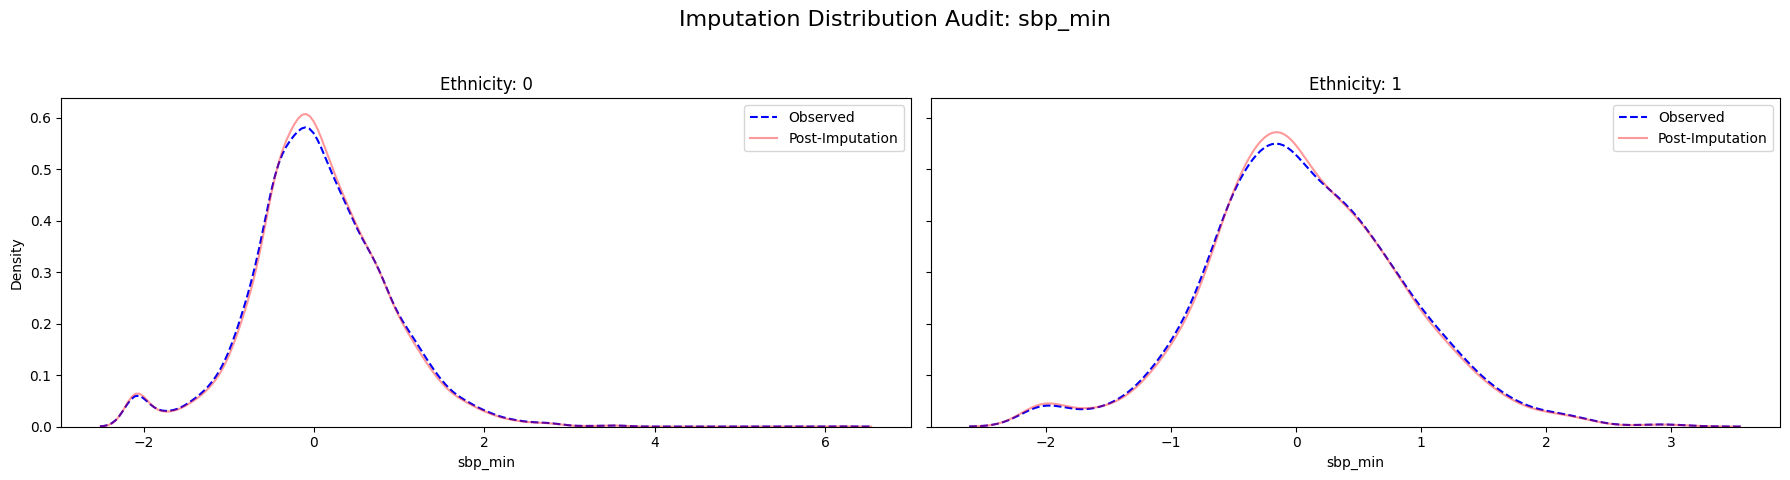

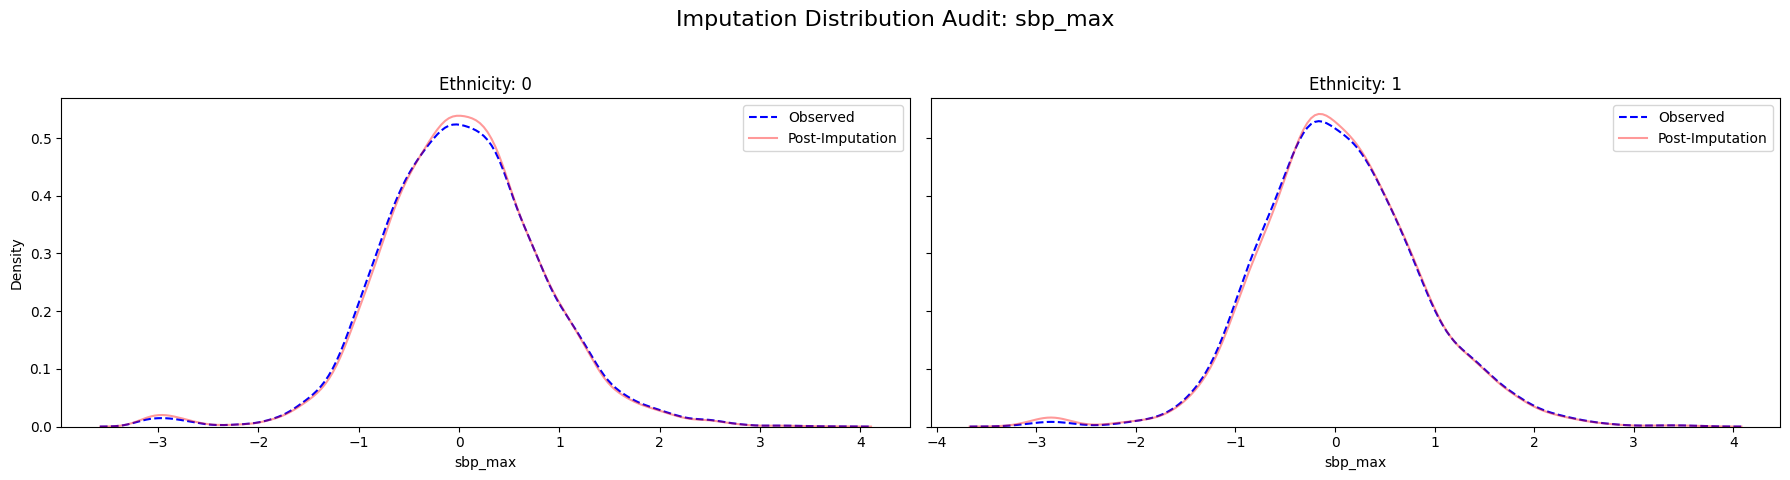

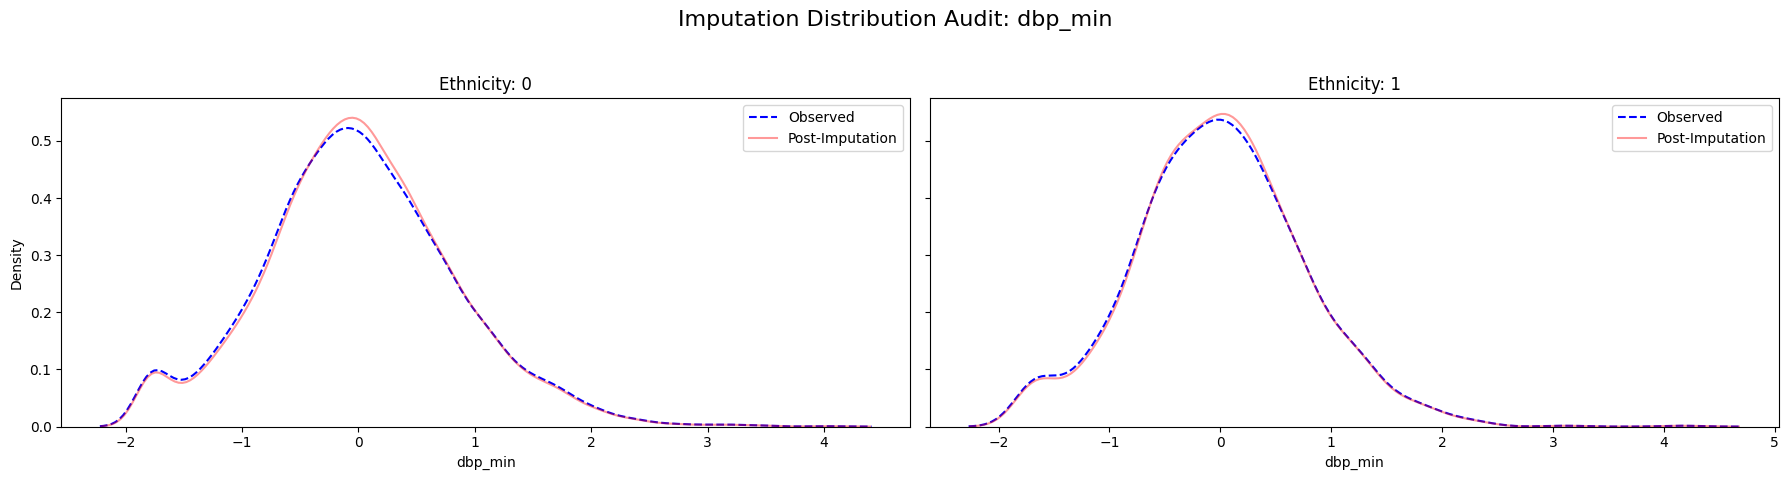

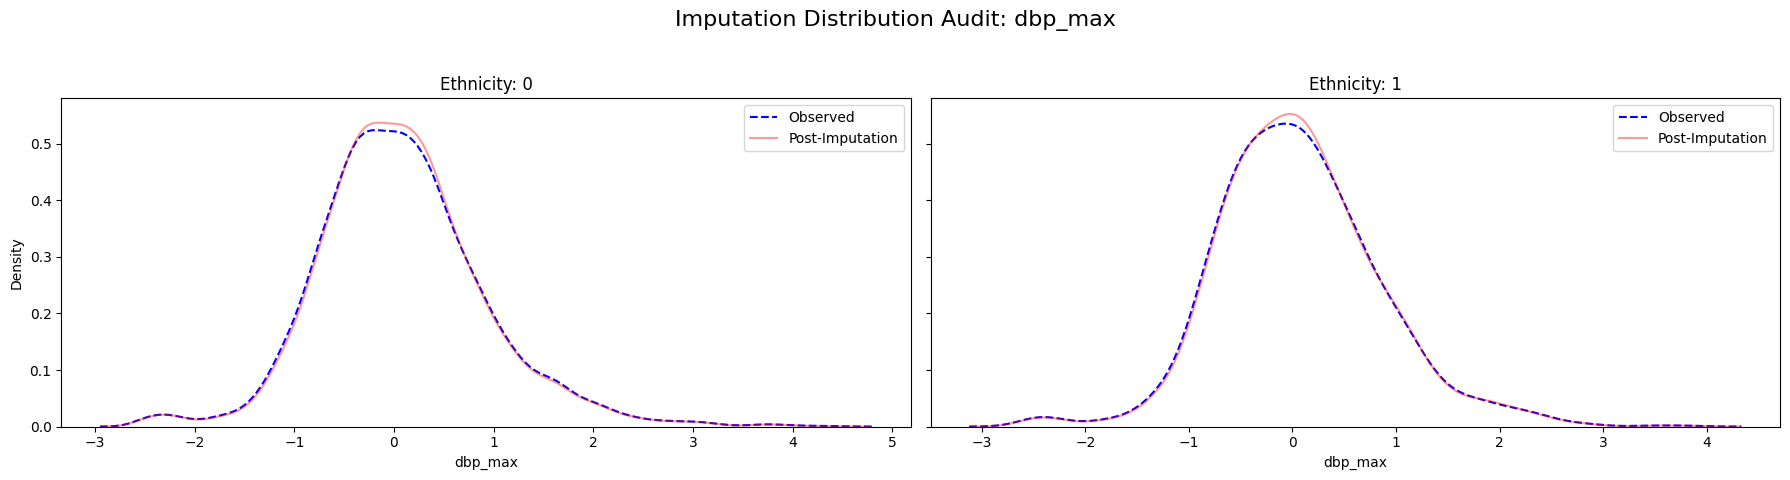

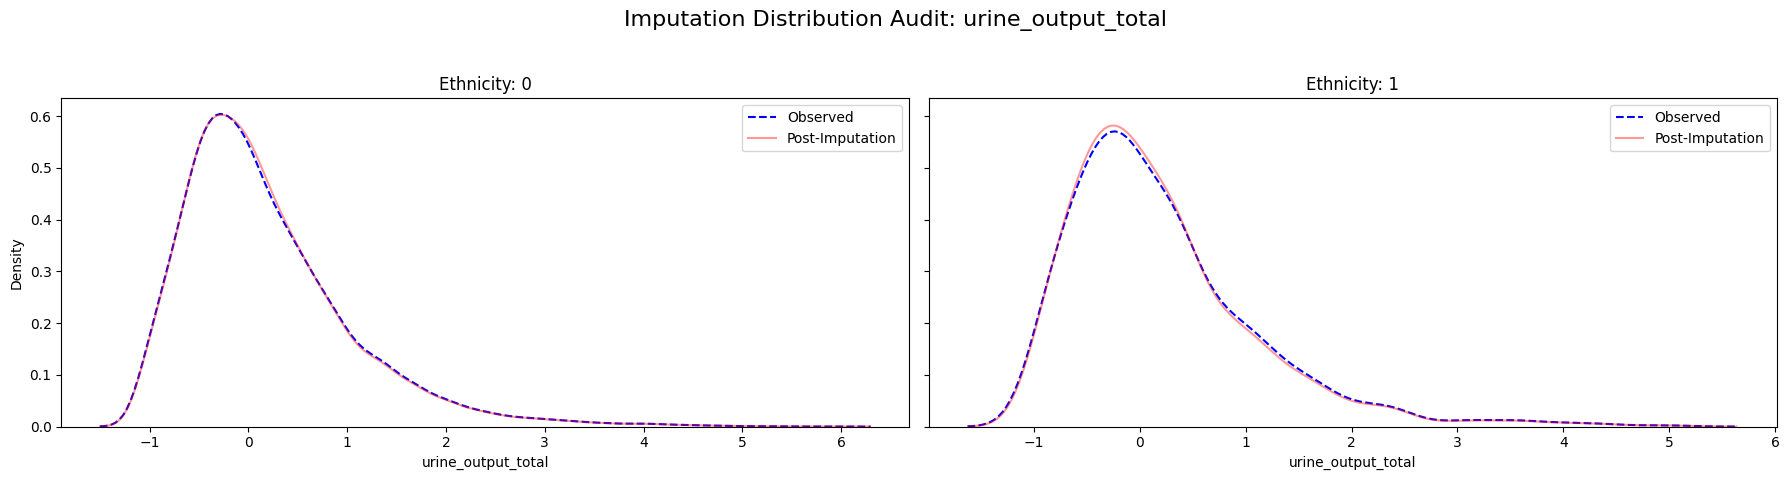

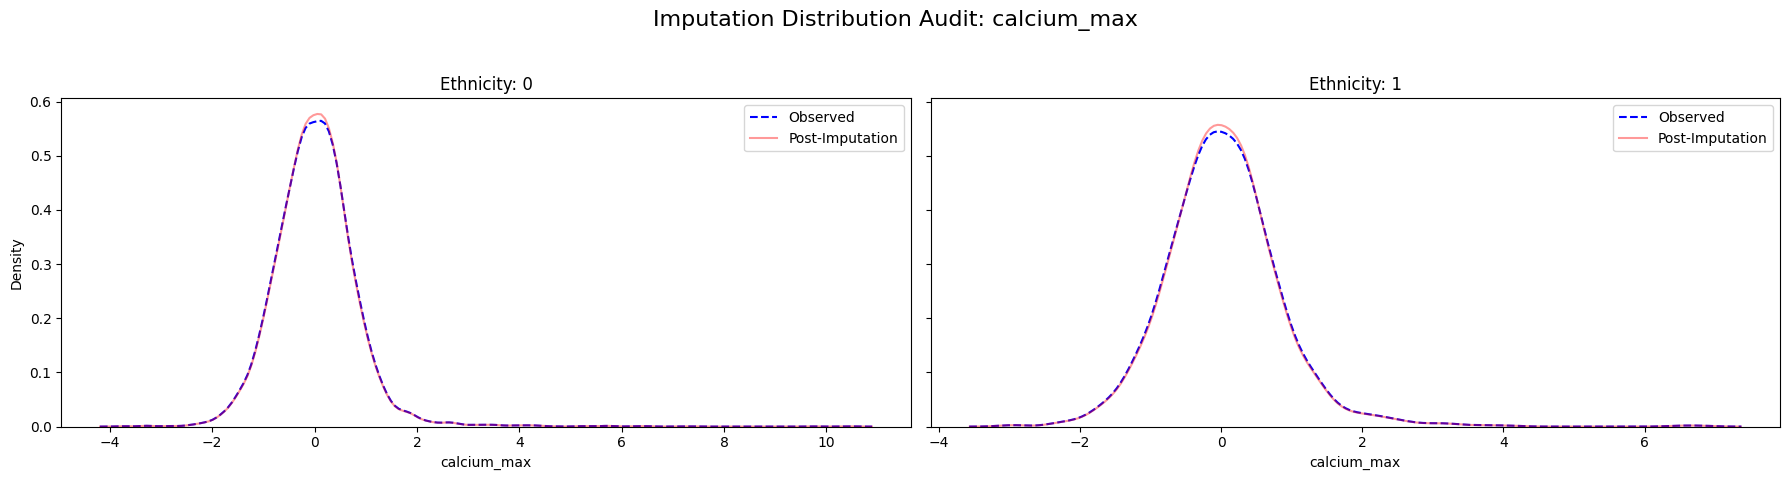

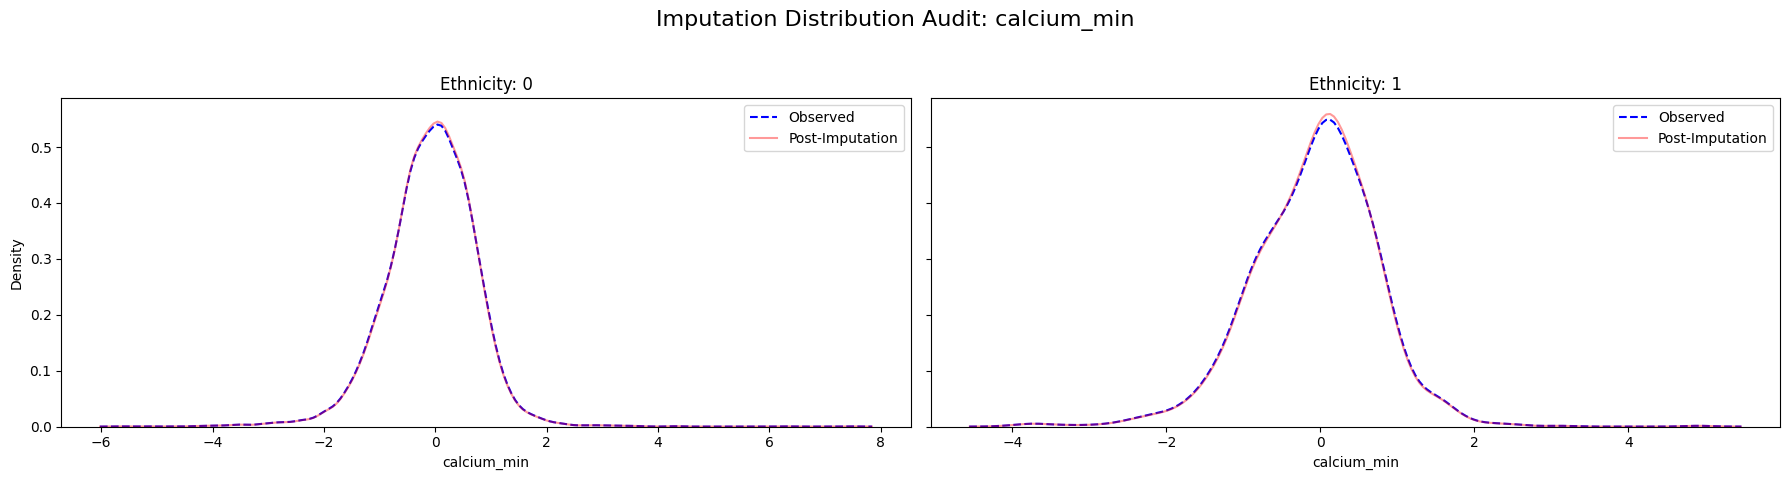

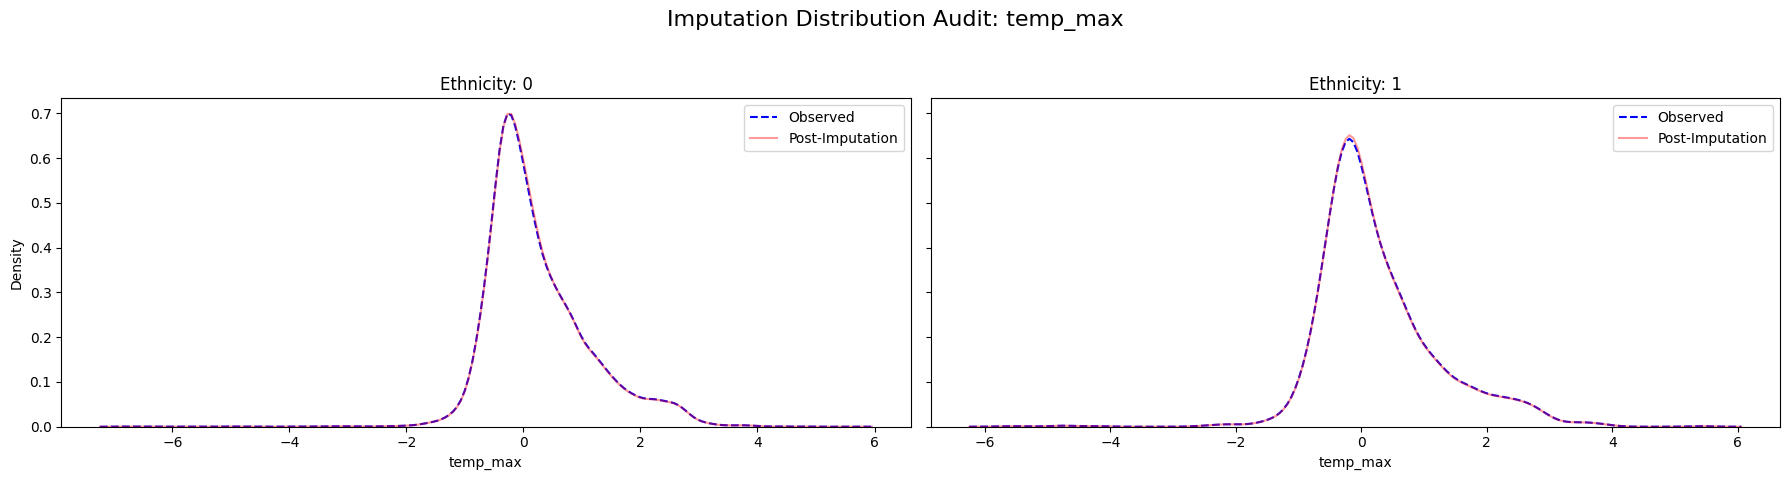

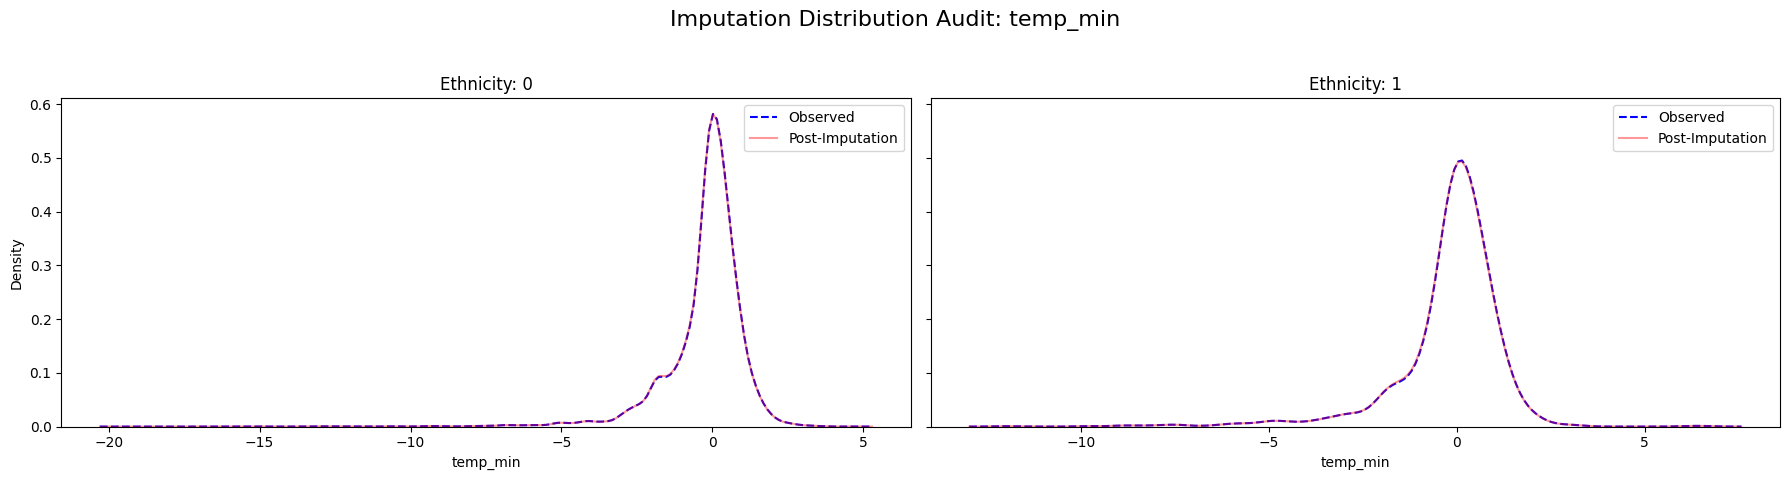

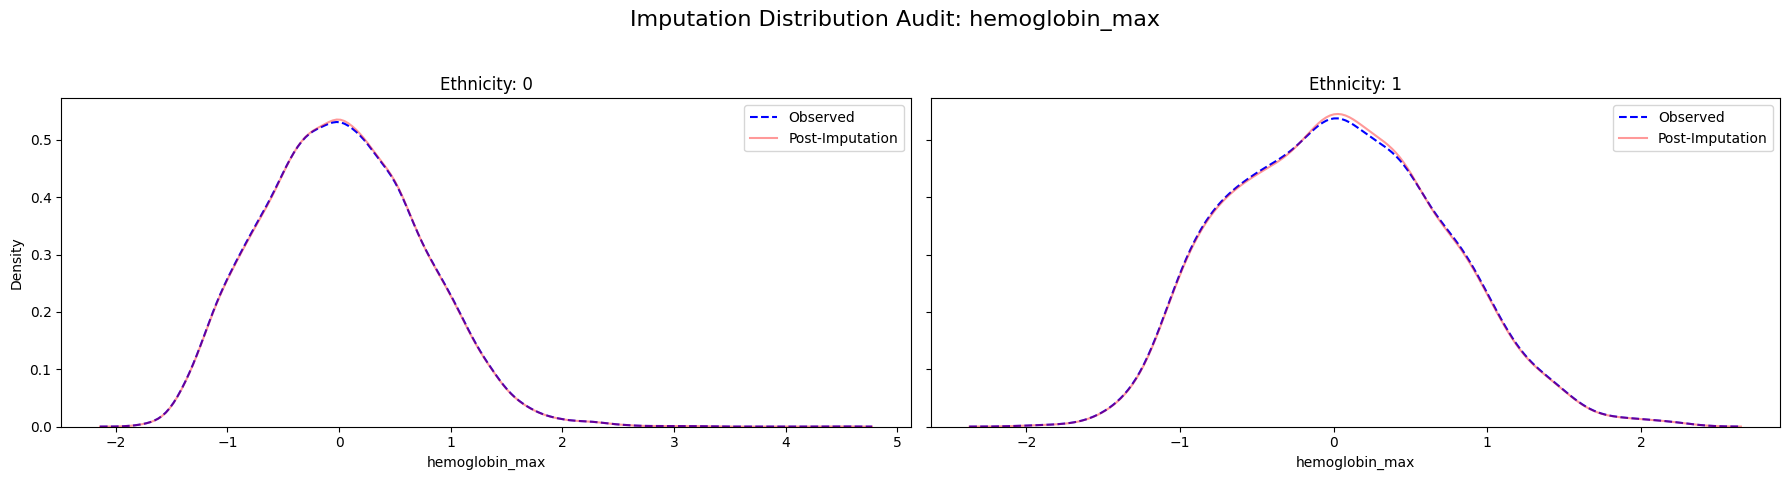

In [26]:
for col in train_top_missing_cols:
  audit_ethnic_imputation(scaled_train_df, imputed_train_dataset, col, ethnicities)

In [27]:
bias_df = calculate_imputation_shift(scaled_train_df, imputed_train_dataset, train_top_missing_cols)
significant_bias = bias_df[bias_df['Internal SMD'].abs() > 0.01]
print(significant_bias.to_markdown(index=False))

|   Ethnicity | Feature            |   Observed Mean |   Imputed Mean |   Internal SMD |   Global SMD |
|------------:|:-------------------|----------------:|---------------:|---------------:|-------------:|
|           0 | dbp_min            |      0.00934189 |      0.0198318 |      0.0125666 |    0.01482   |
|           1 | sbp_min            |      0.0626303  |      0.0541928 |     -0.0108237 |   -0.0069291 |
|           1 | urine_output_total |      0.209792   |      0.193785  |     -0.0178623 |    0.0071759 |


### TEST split

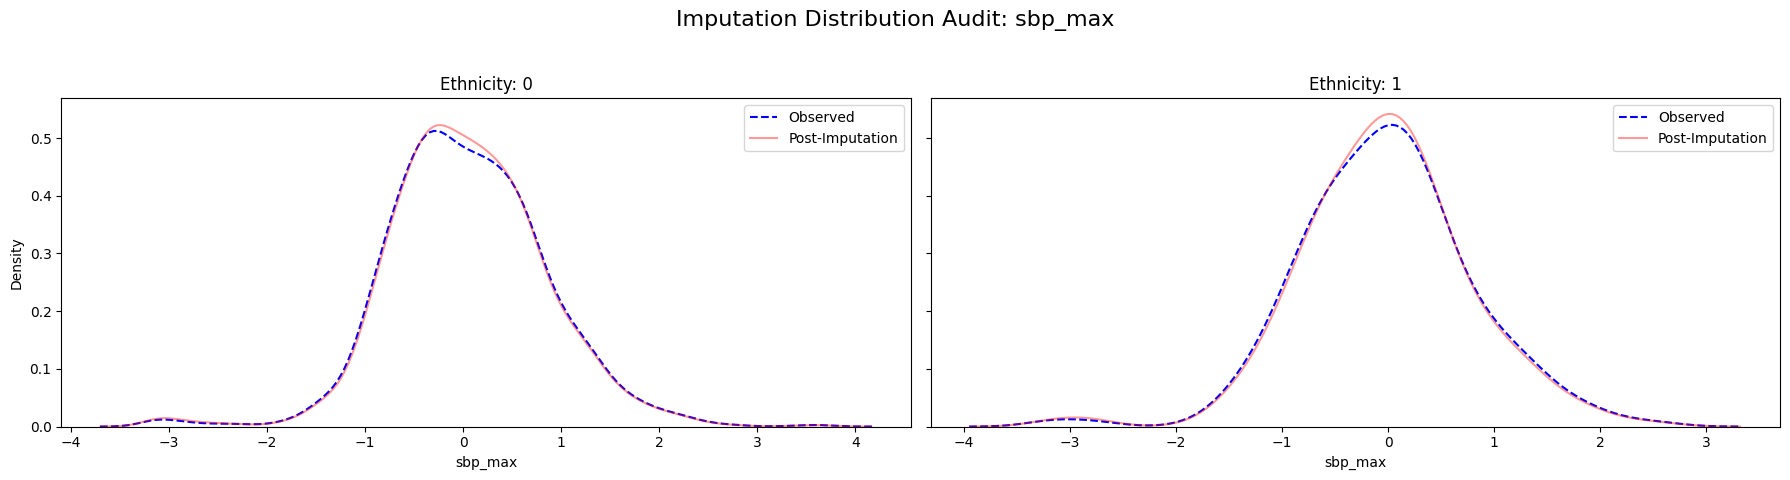

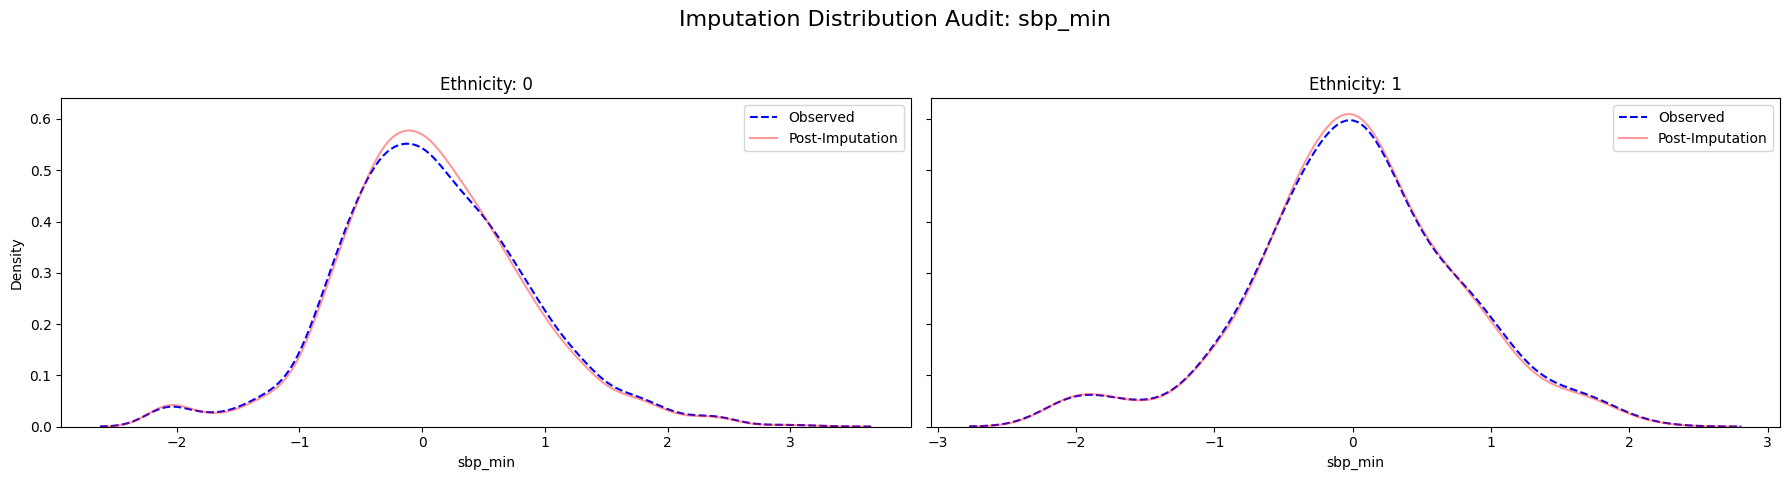

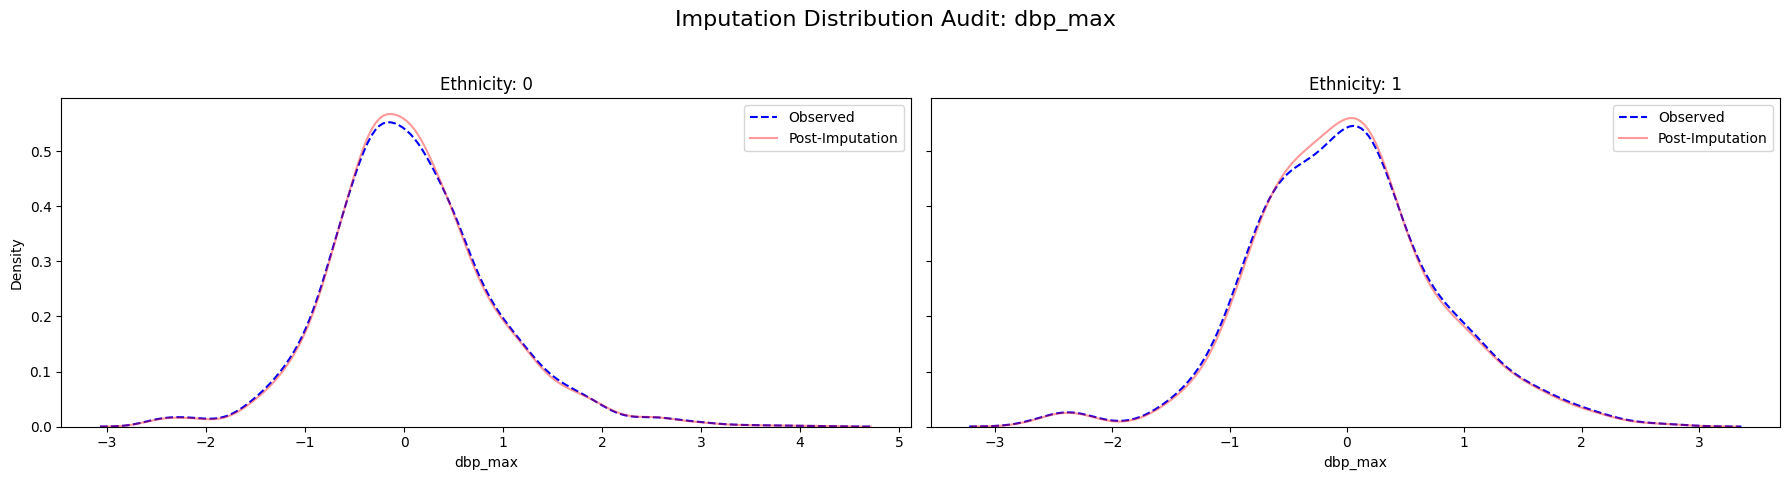

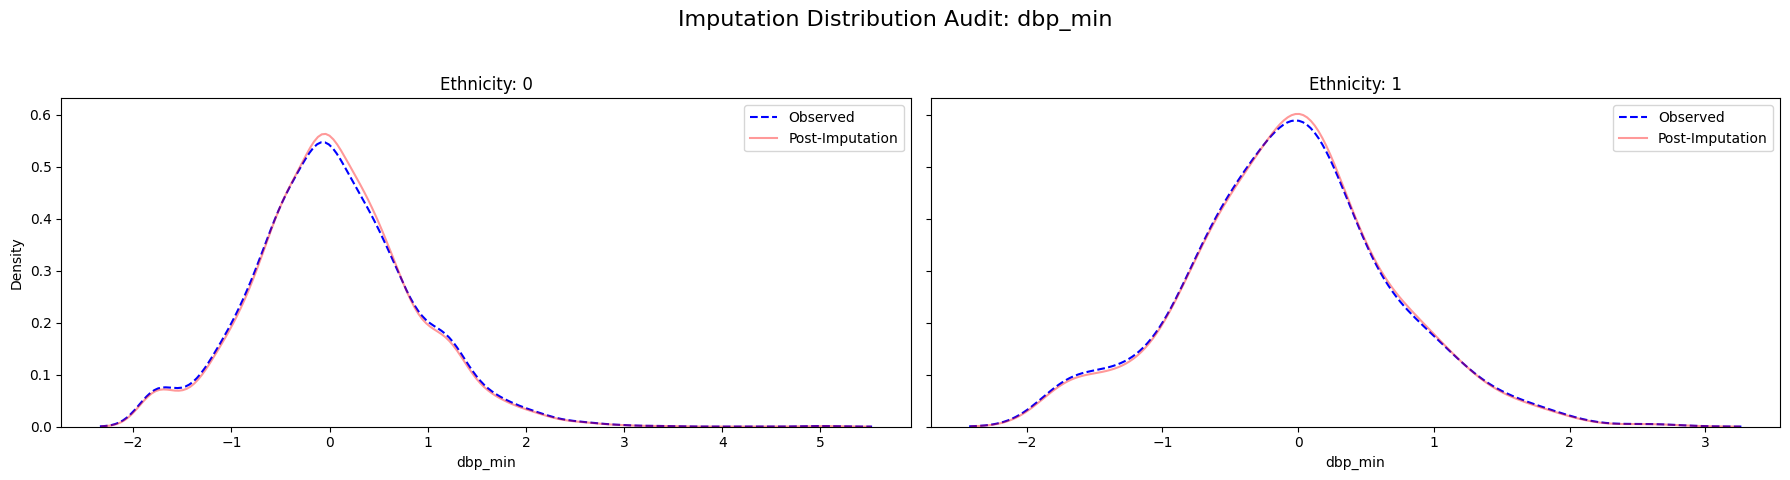

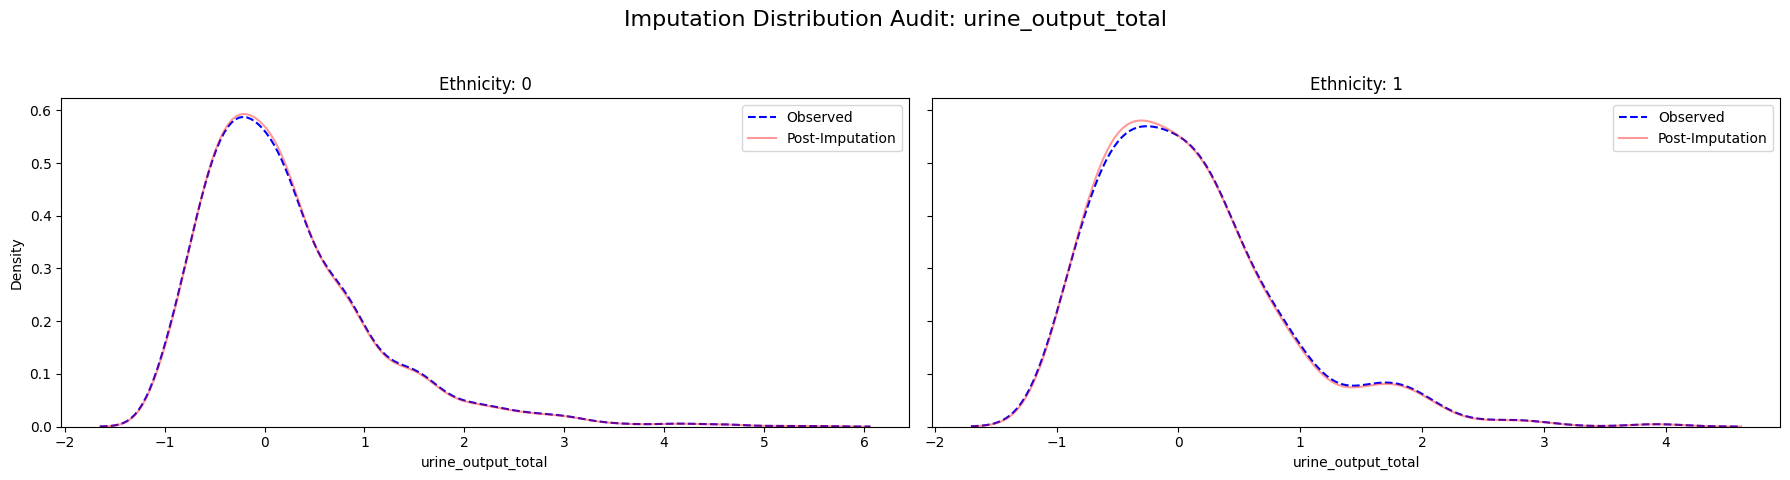

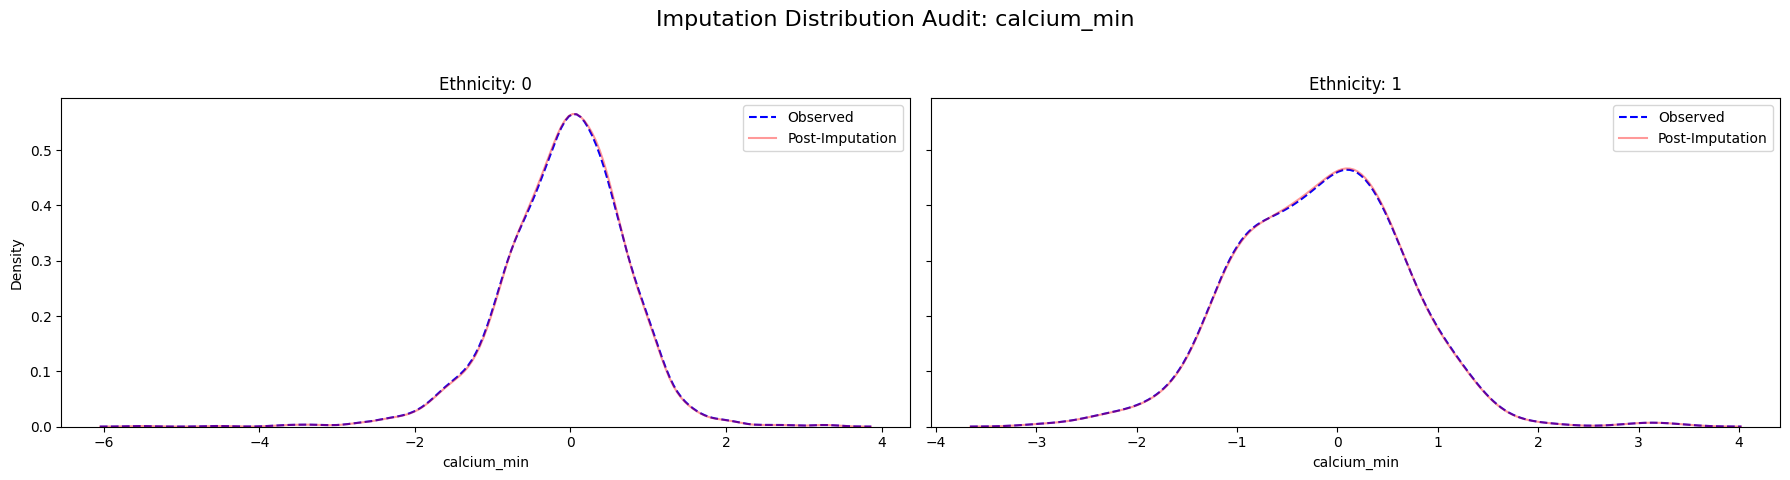

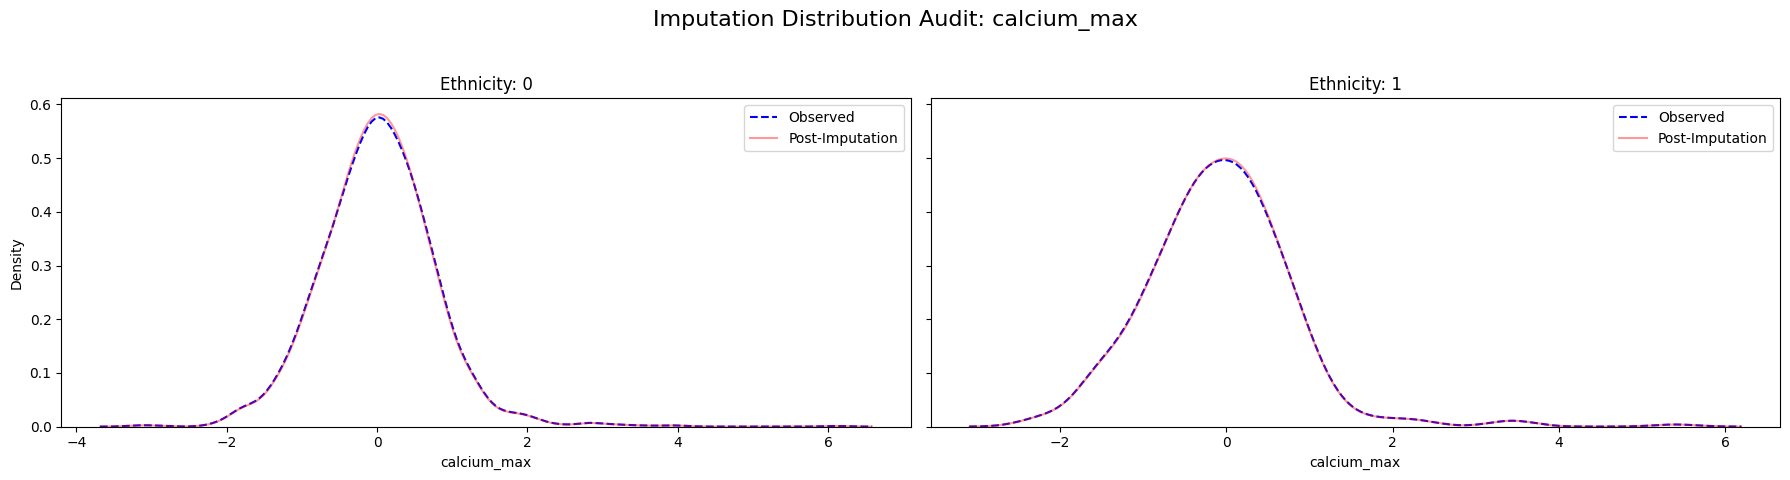

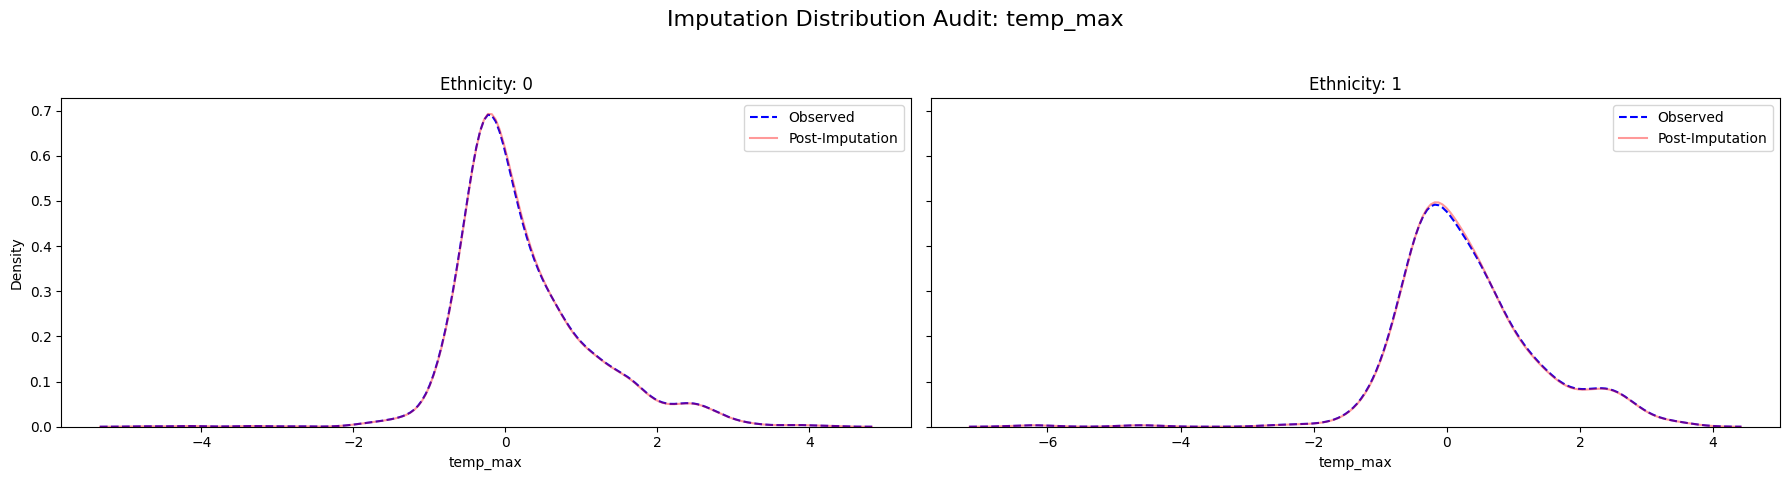

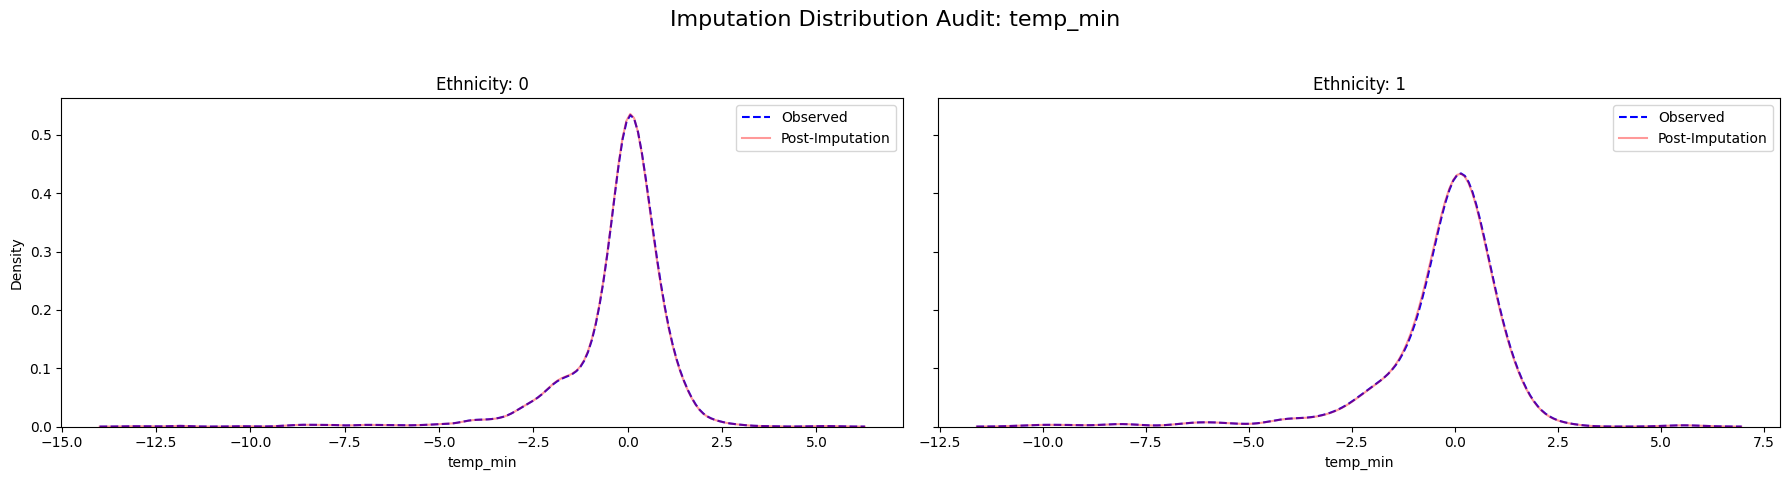

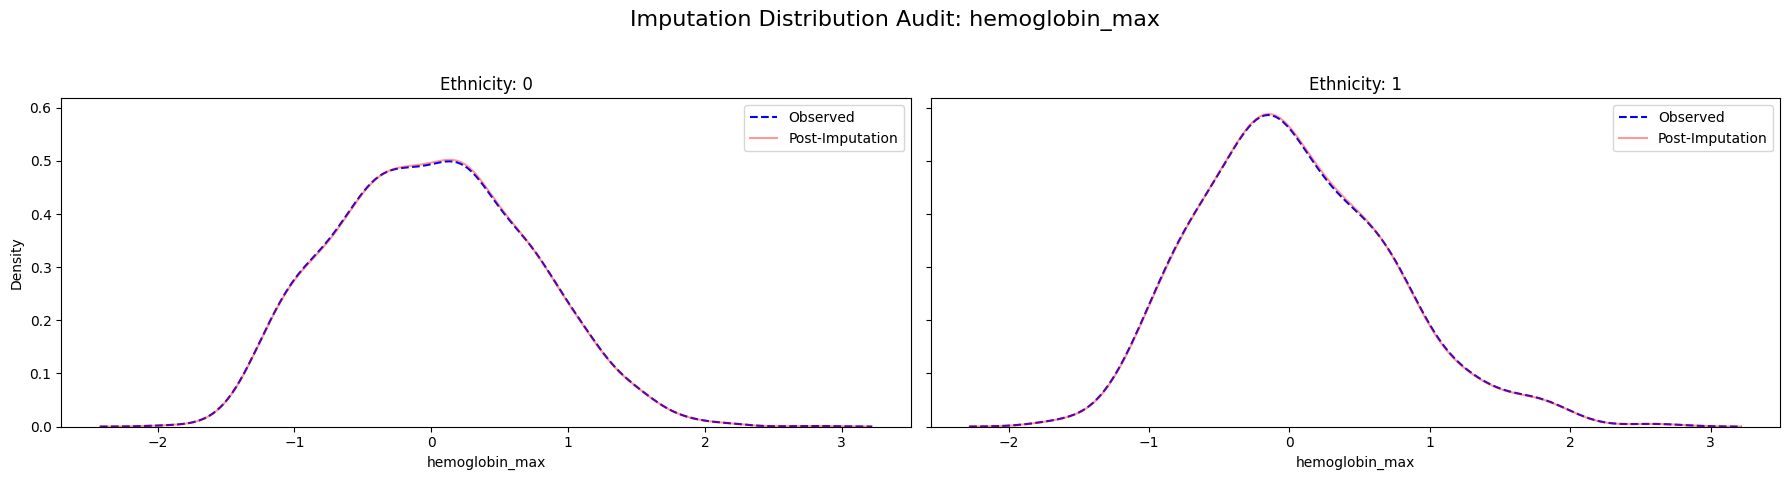

In [28]:
for col in test_top_missing_cols:
  audit_ethnic_imputation(scaled_test_df, imputed_test_dataset, col, ethnicities)

In [29]:
bias_df = calculate_imputation_shift(scaled_test_df, imputed_test_dataset, test_top_missing_cols)
significant_bias = bias_df[bias_df['Internal SMD'].abs() > 0.01]
print(significant_bias.to_markdown(index=False))

|   Ethnicity | Feature            |   Observed Mean |   Imputed Mean |   Internal SMD |   Global SMD |
|------------:|:-------------------|----------------:|---------------:|---------------:|-------------:|
|           0 | sbp_min            |       0.0834607 |      0.0745754 |     -0.0113373 |   0.00404569 |
|           1 | dbp_min            |      -0.0719111 |     -0.0628029 |      0.0121913 |  -0.107424   |
|           1 | urine_output_total |       0.0837426 |      0.0725971 |     -0.0145951 |  -0.160523   |


# Save splits

In [30]:
imputed_test_dataset.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/mimic_iv_test.csv")
imputed_train_dataset.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/mimic_iv_train.csv")

In [31]:
categorical_features = [col for col in imputed_train_dataset if col not in (continuous_features + ['race_group'])]
# TRAIN split: Descriptive statistics
table1 = TableOne(imputed_train_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=False
                  )

print(table1)

                                             Grouped by race_group                            
                                                           Overall             0             1
n                                                            10872          9289          1583
gender, n (%)                            0             5626 (51.7)   4885 (52.6)    741 (46.8)
                                         1             5246 (48.3)   4404 (47.4)    842 (53.2)
admission_age, mean (SD)                                -0.1 (0.8)    -0.1 (0.8)    -0.1 (0.7)
hr_min, mean (SD)                                        0.1 (0.8)     0.1 (0.8)     0.0 (0.7)
hr_max, mean (SD)                                        0.1 (0.8)     0.1 (0.8)     0.1 (0.7)
rr_min, mean (SD)                                        0.1 (0.7)     0.1 (0.7)    -0.0 (0.8)
rr_max, mean (SD)                                        0.1 (0.7)     0.1 (0.7)     0.1 (0.8)
sbp_min, mean (SD)                                

In [32]:
# TEST split: Descriptive statistics
table1 = TableOne(imputed_test_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  missing=False
                  )

print(table1)

                                             Grouped by race_group                           
                                                           Overall             0            1
n                                                             2719          2323          396
gender, n (%)                            0             1427 (52.5)   1238 (53.3)   189 (47.7)
                                         1             1292 (47.5)   1085 (46.7)   207 (52.3)
admission_age, mean (SD)                                -0.1 (0.7)    -0.1 (0.7)   -0.1 (0.7)
hr_min, mean (SD)                                        0.1 (0.7)     0.1 (0.7)    0.0 (0.7)
hr_max, mean (SD)                                        0.1 (0.8)     0.1 (0.8)    0.1 (0.7)
rr_min, mean (SD)                                        0.1 (0.7)     0.1 (0.7)   -0.1 (0.8)
rr_max, mean (SD)                                        0.1 (0.8)     0.1 (0.8)    0.1 (0.8)
sbp_min, mean (SD)                                       0.1

# Prototype classifier

In [33]:
from src.cevaehe_new.causal_validation import run_downstream_probe

probe_results = run_downstream_probe(
  features = imputed_train_dataset.drop(columns=['target_noaf', 'race_group']).values,
  target = imputed_train_dataset['target_noaf'].values,
  sens = imputed_train_dataset['race_group'].values,
  dict_prefix="",
  cf_features=None,
  seed=SEED
)

In [34]:
probe_results_df = pd.DataFrame(probe_results, index=[0])

def format_score(score):
  return round(score*100, 2)

print("---- GLOBAL PERFORMANCE ----\n")
print(probe_results_df.filter(regex="global_.*").apply(format_score).to_markdown(index=False))
for g in [0, 1]:
  group_results = probe_results_df.filter(regex=f"{g}_.*")
  print(f"\n---- GROUP {g} PERFORMANCE ----\n")
  print(group_results.apply(format_score).to_markdown(index=False))

---- GLOBAL PERFORMANCE ----

|   global_mean_auprc |   global_std_auprc |   global_mean_recall |   global_std_recall |   global_mean_precision |   global_std_precision |
|--------------------:|-------------------:|---------------------:|--------------------:|------------------------:|-----------------------:|
|                21.6 |               2.55 |                76.04 |                 2.1 |                   14.09 |                    0.5 |

---- GROUP 0 PERFORMANCE ----

|   0_mean_auprc |   0_std_auprc |   0_mean_recall |   0_std_recall |   0_mean_precision |   0_std_precision |
|---------------:|--------------:|----------------:|---------------:|-------------------:|------------------:|
|          22.61 |          2.43 |           75.83 |           2.31 |              15.01 |               0.4 |

---- GROUP 1 PERFORMANCE ----

|   1_mean_auprc |   1_std_auprc |   1_mean_recall |   1_std_recall |   1_mean_precision |   1_std_precision |
|---------------:|--------------:|-----